<a href="https://colab.research.google.com/github/nuel071003/skripsi/blob/main/Model_Clickbait_Hoax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
clickbait['label'].value_counts()

,count
label,
non-clickbait,4831
clickbait,3169


In [ ]:
X = clickbait["title"]
y = clickbait["label_score"]

print(X.head())
print(y.value_counts())

0    Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...
1    Wow! Ubud Jadi Kota Ke-4 Terbaik Sedunia, Kala...
2    Viral! Driver Ojol di Bekasi Antar Pesanan Mak...
3    Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...
4    MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...
Name: title, dtype: object
label_score
0    4831
1    3169
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train :", len(X_train))
print("Val   :", len(X_val))
print("Test  :", len(X_test))

Train : 6400
Val   : 800
Test  : 800


In [ ]:
from transformers import BartTokenizer

model_name = "facebook/bart-base"

tokenizer = BartTokenizer.from_pretrained(
    model_name
)

print(tokenizer.vocab_size)

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

50265


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

In [ ]:
MAX_LENGTH = 64

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
from transformers import BartForSequenceClassification

model = BartForSequenceClassification.from_pretrained(
    "facebook/bart-base",
    num_labels=2
)

print(model.config.num_labels)

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.dense.weight    | MISSING | 
classification_head.out_proj.bias   | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


2


In [ ]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

val_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(pred):

    labels = pred.label_ids

    predictions = pred.predictions

    # Jika output berupa tuple
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    preds = np.argmax(
        predictions,
        axis=-1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bart_clickbait",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=10,

    weight_decay=1,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    save_total_limit=2,

    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False

In [ ]:
trainer.compute_metrics = compute_metrics

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.440574,0.322418,0.885000,0.887620,0.885000,0.883115
2,0.305926,0.363540,0.890000,0.889659,0.890000,0.889544
3,0.249889,0.457721,0.898750,0.900080,0.898750,0.897562
4,0.201122,0.383527,0.907500,0.907742,0.907500,0.907598
5,0.165329,0.514234,0.908750,0.909196,0.908750,0.908028
6,0.135236,0.641819,0.896250,0.895950,0.896250,0.895982
7,0.098553,0.610022,0.908750,0.908774,0.908750,0.908221
8,0.063985,0.722917,0.900000,0.900210,0.900000,0.899245
9,0.051397,0.683809,0.901250,0.901177,0.901250,0.900677
10,0.036146,0.738243,0.902500,0.902324,0.902500,0.902032


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight'].


TrainOutput(global_step=8000, training_loss=0.16772819805145264, metrics={'train_runtime': 1249.5006, 'train_samples_per_second': 51.22, 'train_steps_per_second': 6.403, 'total_flos': 2453498019840000.0, 'train_loss': 0.16772819805145264, 'epoch': 10.0})

In [ ]:
test_result = trainer.evaluate(test_dataset)

print(test_result)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.036146,0.427603,10,0.931250,0.931566,0.931250,0.930851


{'eval_loss': 0.42760342359542847, 'eval_accuracy': 0.93125, 'eval_precision': 0.9315659342495789, 'eval_recall': 0.93125, 'eval_f1': 0.9308510791960711}


In [ ]:
model.save_pretrained("/content/drive/MyDrive/Berita/model_clickbait")

tokenizer.save_pretrained("/content/drive/MyDrive/Berita/model_clickbait")

print("Model berhasil disimpan")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan


In [ ]:
predictions = trainer.predict(test_dataset)

print(type(predictions.predictions))

<class 'tuple'>


In [ ]:
import numpy as np

predictions = trainer.predict(test_dataset)

logits = predictions.predictions

if isinstance(logits, tuple):
    logits = logits[0]

preds = np.argmax(
    logits,
    axis=-1
)

print(preds[:10])

[0 0 1 1 0 0 0 0 0 1]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    preds
)

print(cm)

[[465  18]
 [ 37 280]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds,
        target_names=[
            "Non-Clickbait",
            "Clickbait"
        ]
    )
)

               precision    recall  f1-score   support

Non-Clickbait       0.93      0.96      0.94       483
    Clickbait       0.94      0.88      0.91       317

     accuracy                           0.93       800
    macro avg       0.93      0.92      0.93       800
 weighted avg       0.93      0.93      0.93       800



In [ ]:
print(cm)

[[465  18]
 [ 37 280]]


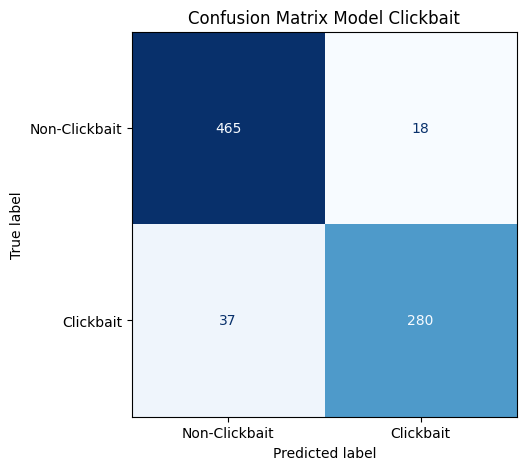

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Clickbait", "Clickbait"]
)

fig, ax = plt.subplots(figsize=(6,5))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix Model Clickbait")
plt.show()

In [ ]:
import pandas as pd

hoax = pd.read_csv(
    "/content/drive/MyDrive/Berita/hoax_berita.csv",
    encoding='latin1'
)

print(hoax.columns)

hoax.head()

Index(['judul', 'narasi', 'label', 'label_score'], dtype='object')


,judul,narasi,label,label_score
0,Ciri-ciri Urine yang Bisa Jadi Tanda Kerusakan...,Perubahan pada urine ternyata bisa menjadi sin...,Non-Hoax,0
1,"Jabodetabek Panas 'Mendidih', Catat Tips dari ...","Beberapa hari terakhir, warga di Jabodetabek d...",Non-Hoax,0
2,Puan Maharani Minta Pemerintah Genjot Penarika...,Ketua DPR RI Puan Maharani meminta pemerintah ...,Hoax,1
3,Dirut PT Taspen Umumkan Program Dana Bantuan u...,"Direktur Utama PT Taspen, Rony Hanityo mengumu...",Hoax,1
4,Prabowo Bolehkan Israel Uji Coba Rudal ke Wila...,Presiden Prabowo Subianto mengatakan bahwa Isr...,Hoax,1


In [ ]:
print(hoax.isnull().sum())

judul          0
narasi         2
label          0
label_score    0
dtype: int64


In [ ]:
hoax['text'] = (hoax['judul'].fillna('') + ' ' + hoax['narasi'].fillna('')).str.strip()

In [ ]:
X = hoax["text"]
y = hoax["label_score"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train :", len(X_train))
print("Val   :", len(X_val))
print("Test  :", len(X_test))

Train : 6000
Val   : 750
Test  : 750


In [ ]:
hoax['label'].value_counts()

,count
label,
Non-Hoax,4173
Hoax,3327


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

In [ ]:
from transformers import BartTokenizer

model_name = "facebook/bart-base"

tokenizer = BartTokenizer.from_pretrained(
    model_name
)

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )


# Tokenisasi dataset training
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# Tokenisasi dataset validation
val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# Tokenisasi dataset testing
test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

print("Tokenisasi selesai.")
print("Train :", train_dataset)
print("Validation :", val_dataset)
print("Test :", test_dataset)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Tokenisasi selesai.
Train : Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 6000
})
Validation : Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 750
})
Test : Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 750
})


In [ ]:
train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

In [ ]:
print(train_dataset)

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 6000
})


In [ ]:
from transformers import BartForSequenceClassification

model = BartForSequenceClassification.from_pretrained(
    "facebook/bart-base",
    num_labels=2
)

print("Model siap")

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.dense.weight    | MISSING | 
classification_head.out_proj.weight | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model siap


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(pred):

    labels = pred.label_ids

    predictions = pred.predictions

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    preds = np.argmax(
        predictions,
        axis=1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./hasil_hoax",

    eval_strategy="epoch",
    save_strategy="epoch",

    num_train_epochs=10,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    logging_steps=50,

    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.135004,0.621235,0.888000,0.903795,0.888000,0.885361
2,0.104791,0.171174,0.961333,0.961498,0.961333,0.961275
3,0.017677,0.299366,0.948000,0.949656,0.948000,0.947743
4,0.029199,0.151237,0.970667,0.970736,0.970667,0.970638
5,0.037882,0.251605,0.953333,0.955055,0.953333,0.953102
6,0.048264,0.315274,0.953333,0.955376,0.953333,0.953079
7,0.033111,0.213233,0.966667,0.966849,0.966667,0.966616
8,0.000280,0.282382,0.960000,0.961360,0.960000,0.959831
9,0.000020,0.254843,0.965333,0.966031,0.965333,0.965233
10,0.000013,0.314147,0.960000,0.961360,0.960000,0.959831


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight'].


TrainOutput(global_step=7500, training_loss=0.07331197762909966, metrics={'train_runtime': 1280.2847, 'train_samples_per_second': 46.865, 'train_steps_per_second': 5.858, 'total_flos': 2300154393600000.0, 'train_loss': 0.07331197762909966, 'epoch': 10.0})

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000013,0.135608,10,0.974667,0.974874,0.974667,0.974628


{'eval_loss': 0.13560843467712402, 'eval_accuracy': 0.9746666666666667, 'eval_precision': 0.9748743507756856, 'eval_recall': 0.9746666666666667, 'eval_f1': 0.9746275321077434}


In [ ]:
import numpy as np

predictions = trainer.predict(test_dataset)

logits = predictions.predictions

if isinstance(logits, tuple):
    logits = logits[0]

preds = np.argmax(logits, axis=1)

print(preds[:10])

[0 1 0 0 1 0 1 0 1 1]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds,
        target_names=[
            "Non-Hoax",
            "Hoax"
        ]
    )
)

              precision    recall  f1-score   support

    Non-Hoax       0.97      0.99      0.98       418
        Hoax       0.98      0.96      0.97       332

    accuracy                           0.97       750
   macro avg       0.98      0.97      0.97       750
weighted avg       0.97      0.97      0.97       750



In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/Berita/model_hoax"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/Berita/model_hoax"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Berita/model_hoax/tokenizer_config.json',
 '/content/drive/MyDrive/Berita/model_hoax/tokenizer.json')

In [ ]:
import numpy as np

predictions = trainer.predict(test_dataset)

logits = predictions.predictions

if isinstance(logits, tuple):
    logits = logits[0]

preds = np.argmax(logits, axis=1)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    preds
)

print(cm)

[[413   5]
 [ 14 318]]


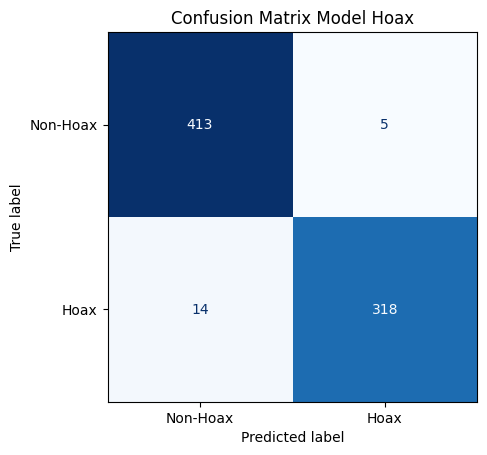

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Hoax", "Hoax"]
)

disp.plot(
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix Model Hoax")

plt.savefig(
    "/content/drive/MyDrive/Berita/confusion_matrix_hoax.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()